In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
%matplotlib inline

from bs4 import BeautifulSoup 
import re
import unidecode
import nltk
from nltk.stem.wordnet import WordNetLemmatizer
from nltk.corpus import stopwords # import stopwords
nltk.download('omw-1.4')

import warnings
warnings.filterwarnings("ignore")

[nltk_data] Downloading package omw-1.4 to /usr/share/nltk_data...


# 1: EDA

Lets examine our data

In [2]:
df = pd.read_csv("/kaggle/input/nlp-getting-started/train.csv")
df.head()

,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        7613 non-null   int64 
 1   keyword   7552 non-null   object
 2   location  5080 non-null   object
 3   text      7613 non-null   object
 4   target    7613 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 297.5+ KB


In [4]:
df.describe(include='all')

,id,keyword,location,text,target
count,7613.000000,7552,5080,7613,7613.00000
unique,NaN,221,3341,7503,NaN
top,NaN,fatalities,USA,11-Year-Old Boy Charged With Manslaughter of T...,NaN
freq,NaN,45,104,10,NaN
mean,5441.934848,NaN,NaN,NaN,0.42966
std,3137.116090,NaN,NaN,NaN,0.49506
min,1.000000,NaN,NaN,NaN,0.00000
25%,2734.000000,NaN,NaN,NaN,0.00000
50%,5408.000000,NaN,NaN,NaN,0.00000
75%,8146.000000,NaN,NaN,NaN,1.00000


In [5]:
df.duplicated().sum()

0

In [6]:
df.text.isna().sum()

0

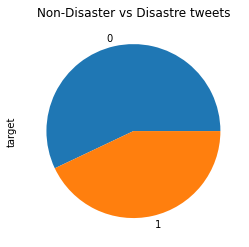

In [7]:
df.target.value_counts().plot.pie()
plt.title("Non-Disaster vs Disastre tweets");

In [8]:
# display a disaster tweet example
df[df['target'] == 1]['text'].values[1234]

'Student electrocuted to death in school campus http://t.co/ryah8Fni5Q'

In [9]:
# display a non disaster tweet example
df[df['target'] == 0]['text'].values[1234]

"@TheLegendBlue @Cozmo23 they'll probably allow us to ascend them but not get them to the damage max values"

### Visualize Row Tweets

this helps us decide what steps to include in our preprocessing step

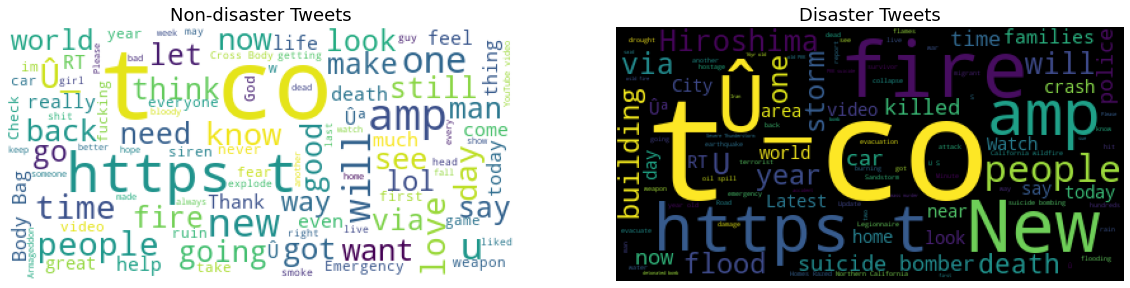

In [10]:
from wordcloud import WordCloud

# Combine all reviews for the positive sentiment
disaster_text = " ".join([review for review in df[df['target'] == 1]['text']])
non_disaster_text = " ".join([review for review in df[df['target'] == 0]['text']])

# Initialize wordcloud object
wc_white = WordCloud(background_color='white', max_words=100)
wc_dark  = WordCloud(max_words=100)

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(20,20))

# Generate and plot wordcloud
ax[0].imshow(wc_white.generate(non_disaster_text))
ax[0].axis('off')
ax[0].set_title('Non-disaster Tweets', fontsize=18)

ax[1].imshow(wc_dark.generate(disaster_text))
ax[1].axis('off')
ax[1].set_title('Disaster Tweets', fontsize=18)
plt.show()

# 2: Data Preprocessing

We'll prepare text data from different sources with the following text processing steps:

- Cleaning to remove irrelevant items, such as HTML tags
- Normalizing by converting to all lowercase and removing punctuation
- Splitting text into words or tokens
- Removing words that are too common, also known as stop words
- Remove words of length less than 3 
- Remove words containing numbers
- Remove special charachters
- Remove Emojis
- Converting words into their dictionary forms, using stemming and lemmatization

After performing these steps, the text will capture the essence of what was being conveyed in a form that is easier to work with.

In [11]:
# Remove Accented Characters, or use strip_accents='unicode' in CountVectorizer
unidecode.unidecode('Málaga, àéêöhello')

'Malaga, aeeohello'

In [12]:
# https://stackoverflow.com/questions/33404752/removing-emojis-from-a-string-in-python
def remove_emojis(text):
    emoj = re.compile("["
        u"\U0001F600-\U0001F64F"  # emoticons
        u"\U0001F300-\U0001F5FF"  # symbols & pictographs
        u"\U0001F680-\U0001F6FF"  # transport & map symbols
        u"\U0001F1E0-\U0001F1FF"  # flags (iOS)
        u"\U00002500-\U00002BEF"  # chinese char
        u"\U00002702-\U000027B0"
        u"\U00002702-\U000027B0"
        u"\U000024C2-\U0001F251"
        u"\U0001f926-\U0001f937"
        u"\U00010000-\U0010ffff"
        u"\u2640-\u2642" 
        u"\u2600-\u2B55"
        u"\u200d"
        u"\u23cf"
        u"\u23e9"
        u"\u231a"
        u"\ufe0f"                 # dingbats
        u"\u3030"
                      "]+", flags=re.UNICODE)
    return re.sub(emoj, '', text).strip()

text = "Hi 🤔 How is your 🙈 and 😌. Have a nice weekend 💕👭👙"
print(text)                      # with emoji
remove_emojis(text)              # without emoji

Hi 🤔 How is your 🙈 and 😌. Have a nice weekend 💕👭👙


'Hi  How is your  and . Have a nice weekend'

In [13]:
lemmatizer = WordNetLemmatizer()
# stopwords in English + common words between the 2 classes
stop_words = stopwords.words('english') + ['co','https', 'http', 'new', 't',
                                          'Û', 'U', 'u', 'amp', 'via', 'one']

def tokenize(text):
    """make text ready to feed it to models"""
    soup = BeautifulSoup(text, "html.parser")
    text = soup.get_text(separator=" ")                # Strip HTML Tags
    text = text.lower().strip()                        # Convert to lowercase & Remove Whitespaces
    text = re.sub(r'http\S+', '', text)                # Remove links
    text = re.sub(r"[^a-zA-Z0-9]", " ", text)          # Remove special charachters
    text = re.sub(r"[^a-zA-Z0-9:$-,%.?!]+", ' ', text) # Remove Special Characters within words
    text = re.sub(r"[^a-zA-Z:$-,%.?!]+", ' ', text)    # Remove numbers from the text 
    text = unidecode.unidecode(text)                   # Remove Accented Characters, or use strip_accents='unicode' in CountVectorizer
    text = re.sub(r'\b\w{1,2}\b', '', text)            # Remove words of length less than 2 
    text = re.sub(r'\w*\d\w*', '', text)               # Remove words containing numbers
    text = remove_emojis(text)                         # Remove Emojis
    
    tokens = nltk.word_tokenize(text)
    lemmas = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return lemmas 

print("Original text:", df.text[0], '\n')
print("Pre-processed Text:", tokenize(df.text[0]))

Original text: Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all 

Pre-processed Text: ['deed', 'reason', 'earthquake', 'may', 'allah', 'forgive']


### Visualize Preprocessed Tweets

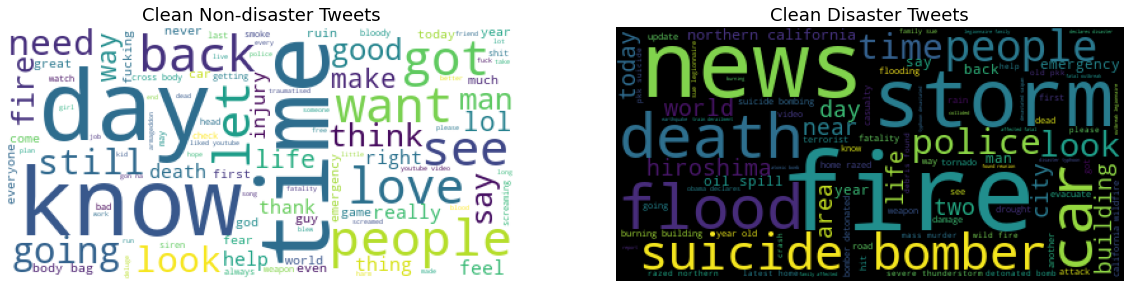

In [14]:
df['clean_text'] = df.text.map(tokenize)

# Combine all reviews for the positive sentiment
disaster_text = " ".join([" ".join(review) for review in df[df['target'] == 1]['clean_text']])
non_disaster_text = " ".join([" ".join(review) for review in df[df['target'] == 0]['clean_text']])

# Initialize wordcloud object
wc_white = WordCloud(background_color='white', max_words=100)
wc_dark  = WordCloud(max_words=100)

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(20,20))

# Generate and plot wordcloud
ax[0].imshow(wc_white.generate(non_disaster_text))
ax[0].axis('off')
ax[0].set_title('Clean Non-disaster Tweets', fontsize=18)

ax[1].imshow(wc_dark.generate(disaster_text))
ax[1].axis('off')
ax[1].set_title('Clean Disaster Tweets', fontsize=18)
plt.show()

Now we can easly seperate the tweet between the 2 classes. 👏

# 3. Modeling

We will split the dataset to evaluate our models

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df.text, df.target, test_size=0.2, random_state=10)
X_train.shape, X_test.shape

((6090,), (1523,))

## 3.1 Dummy Classifier

It is often a good idea to have a few baseline metrics, or else we may end up thinking our model works great when in fact it is doing worse than basic models.

In [16]:
from sklearn.dummy import DummyClassifier

dummy_clf = DummyClassifier(strategy="most_frequent")
dummy_clf.fit(X_train, y_train)

DummyClassifier(strategy='most_frequent')

In [17]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

y_pred = dummy_clf.predict(X_test)
print('Accuracy', round(accuracy_score(y_test, y_pred), 4)*100, '%')
print('Precision', round(precision_score(y_test, y_pred), 2)*100, '%')
print('Recall', round(recall_score(y_test, y_pred), 2)*100, '%')

Accuracy 56.53 %
Precision 0.0 %
Recall 0.0 %


If you predict any tweet as a Non-Disaster tweet (the most frequent), you will get an accuracy of 56%, Lets see if we can do better!

## 3.2 Build a Pipeline (a Better Model)

I LOOOVE piplines, It's clean, consise, and help you alot during the hyperparameter tuning phase.

Lets create new features to add to our pipeline after converting the tweets to a Bag-of-words using CountVectorizer & TfidfTransformer

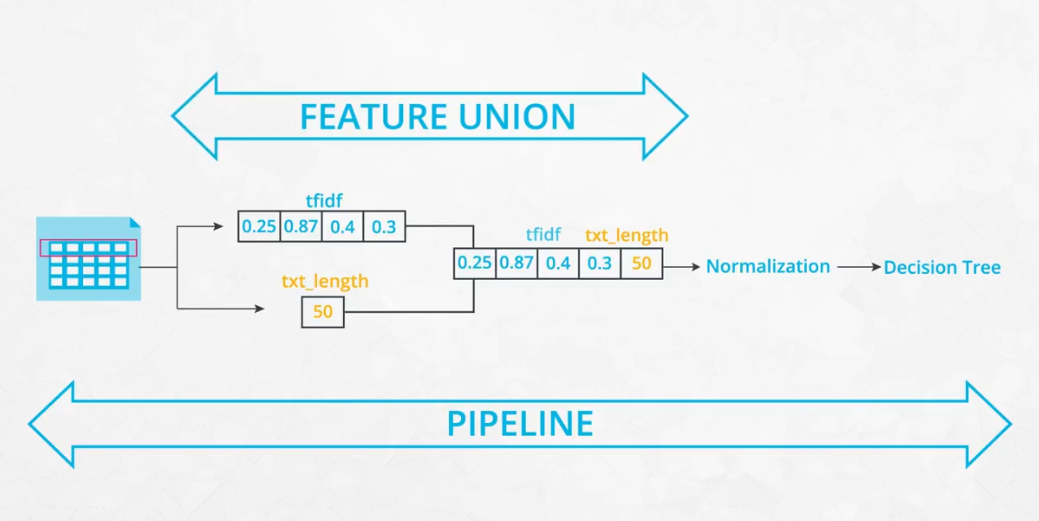

In [18]:
from sklearn.base import BaseEstimator, TransformerMixin

class TextLength(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X_length = pd.Series(X).str.len()
        return pd.DataFrame(X_length)
    
class LinkExtractor(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        containsLink = pd.Series(X).str.contains('http')
        return pd.DataFrame(containsLink)
    
class StartingVerbExtractor(BaseEstimator, TransformerMixin):

    def starting_verb(self, text):
        sentence_list = nltk.sent_tokenize(text)
        for sentence in sentence_list:
            pos_tags = nltk.pos_tag(tokenize(sentence))
            # print(pos_tags, sentence)
            if len(pos_tags) > 0:
                first_word, first_tag = pos_tags[0]
                if first_tag in ['VB', 'VBP']: 
                    return True
        return False

    def fit(self, x, y=None):
        return self

    def transform(self, X):
        X_tagged = pd.Series(X).apply(self.starting_verb)
        return pd.DataFrame(X_tagged)

In [19]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import BernoulliNB
from catboost import CatBoostClassifier

pipeline = Pipeline([
    ('features', FeatureUnion([
        ('text_preprocessor', Pipeline([
            ('victorizer', CountVectorizer(tokenizer=tokenize, min_df=3, ngram_range=(1,2))), # Combine 'thank you' into one term (bi-grams)
#             ('tfidf', TfidfTransformer())
        ])),
        ('contains_link', LinkExtractor()),
        ('text_length', TextLength()),
        ('starting_verb', StartingVerbExtractor())
    ])),
    ('clf', VotingClassifier(estimators=[("bernoulli", BernoulliNB()),
                                         ("lr", LogisticRegression(random_state=10, max_iter=800)),
                                         ("cat", CatBoostClassifier(random_state=10, verbose=0))],
                             n_jobs=-1, voting='soft'))
])

# train the pipeline
pipeline.fit(X_train, y_train)

Pipeline(steps=[('features',
                 FeatureUnion(transformer_list=[('text_preprocessor',
                                                 Pipeline(steps=[('victorizer',
                                                                  CountVectorizer(min_df=3,
                                                                                  ngram_range=(1,
                                                                                               2),
                                                                                  tokenizer=<function tokenize at 0x7fe10b049e60>))])),
                                                ('contains_link',
                                                 LinkExtractor()),
                                                ('text_length', TextLength()),
                                                ('starting_verb',
                                                 StartingVerbExtractor())])),
                ('clf',
                

In [20]:
# Evaluate the pipeline
from sklearn.metrics import classification_report, accuracy_score, recall_score, precision_score

y_pred = pipeline.predict(X_test)

print('Accuracy', round(accuracy_score(y_test, y_pred), 4)*100, '%')
print('Precision', round(precision_score(y_test, y_pred), 2)*100, '%')
print('Recall', round(recall_score(y_test, y_pred), 2)*100, '%')
print(classification_report(y_test, y_pred, target_names=['Not Disaster', 'Disaster'])) # [0, 1]

Accuracy 80.30000000000001 %
Precision 87.0 %
Recall 64.0 %
              precision    recall  f1-score   support

Not Disaster       0.77      0.93      0.84       861
    Disaster       0.87      0.64      0.74       662

    accuracy                           0.80      1523
   macro avg       0.82      0.78      0.79      1523
weighted avg       0.81      0.80      0.80      1523



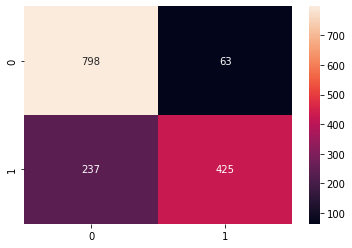

In [21]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

# plot the confusion matrix
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='.4g');

In [22]:
# preview the pipeline parameters to evaluate them later
pipeline.get_params()

{'memory': None,
 'steps': [('features',
   FeatureUnion(transformer_list=[('text_preprocessor',
                                   Pipeline(steps=[('victorizer',
                                                    CountVectorizer(min_df=3,
                                                                    ngram_range=(1,
                                                                                 2),
                                                                    tokenizer=<function tokenize at 0x7fe10b049e60>))])),
                                  ('contains_link', LinkExtractor()),
                                  ('text_length', TextLength()),
                                  ('starting_verb', StartingVerbExtractor())])),
  ('clf',
   VotingClassifier(estimators=[('bernoulli', BernoulliNB()),
                                ('lr',
                                 LogisticRegression(max_iter=800,
                                                    random_state=10)),
    

### Pipeline Hyperparameter Tuning

here, you can use any Hyperparameter tuning libraries, but for simplicity I will use `RandomizedSearchCV`

In [23]:
# from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

# paramseters = {'features__text_preprocessor__tfidf__use_idf': [True, False],
#               'features__text_preprocessor__tfidf__sublinear_tf': [True, False],
#               'features__text_preprocessor__victorizer__ngram_range': [(1,1), (1,2), (1,3)],
#               'features__text_preprocessor__victorizer__max_features': [None, 1000, 5000],
#               'features__text_preprocessor__victorizer__min_df': [3, 5, 8],
#               'features__text_preprocessor__victorizer__max_df': [3, 5, 8],
#               'clf__bernoulli__alpha': [0.1, 0.5, 1],
#               'clf__bernoulli__fit_prior': [True, False],
#               'clf__lr__C': [0.1, 0.5, 1],
#               'clf__lr__tol': [0.00001, 0.0001, 0.005 ,0.001, 0.01],
#               'clf__lr__dual': [True, False],
#               'clf__lr__penalty': ['l2', 'l1', 'elasticnet'],
#               'clf__lr__solver': ['liblinear', 'lbfgs', 'newton-cholesky'],
#               'clf__lr__warm_start': [True, False],
#               'clf__cat__iterations': [10000, 13000, 16000, 20000],
#               'clf__cat__learning_rate': [0.00001, 0.0001, 0.005 ,0.001, 0.01],
#               'clf__cat__depth': [2, 4, 8],
#               'clf__cat__l2_leaf_reg': [0.1, 0.5, 1],
#               'clf__cat__early_stopping_rounds': [100, 200, 400, 600]
#              }

# grid = RandomizedSearchCV(pipeline, cat_params_distributions=cat_paramseters, n_jobs=-1,
#                          cv=3, n_iter=400, verbose=2)
# grid.fit(X_train, y_train)

# print("Best score:", grid.best_score_)
# grid.best_estimator_

In [24]:
# use RandomizedSearchCV results to create a better pipeline
better_pipeline = Pipeline([
    ('features', FeatureUnion([
        ('text_preprocessor', Pipeline([
            ('victorizer', CountVectorizer(tokenizer=tokenize, min_df=3, ngram_range=(1,2))),  
#             ('tfidf', TfidfTransformer())
        ])),
        ('contains_link', LinkExtractor()),
        ('text_length', TextLength()),
        ('starting_verb', StartingVerbExtractor())
    ])),
    ('clf', VotingClassifier(estimators=[("bernoulli", BernoulliNB(alpha=0.6, binarize=0.9)),
                                         ("lr", LogisticRegression(random_state=10, max_iter=1500, C=1, tol=0.001)),
                                         ("cat", CatBoostClassifier(random_state=10, verbose=0, iterations=16000,
                                                                    learning_rate=0.005, l2_leaf_reg=1,
                                                                    depth=4, early_stopping_rounds=200))],
                             weights=(1,1,2), n_jobs=-1, voting='soft'))
])

# train the new pipeline
better_pipeline.fit(X_train, y_train)

Pipeline(steps=[('features',
                 FeatureUnion(transformer_list=[('text_preprocessor',
                                                 Pipeline(steps=[('victorizer',
                                                                  CountVectorizer(min_df=3,
                                                                                  ngram_range=(1,
                                                                                               2),
                                                                                  tokenizer=<function tokenize at 0x7fe10b049e60>))])),
                                                ('contains_link',
                                                 LinkExtractor()),
                                                ('text_length', TextLength()),
                                                ('starting_verb',
                                                 StartingVerbExtractor())])),
                ('clf',
                

In [25]:
# Evaluate the new pipeline
y_pred = better_pipeline.predict(X_test)

print('Accuracy', round(accuracy_score(y_test, y_pred), 4)*100, '%')
print('Precision', round(precision_score(y_test, y_pred), 2)*100, '%')
print('Recall', round(recall_score(y_test, y_pred), 2)*100, '%')
print(classification_report(y_test, y_pred, target_names=['Not Disaster', 'Disaster'])) # [0, 1]

Accuracy 81.08999999999999 %
Precision 86.0 %
Recall 67.0 %
              precision    recall  f1-score   support

Not Disaster       0.78      0.92      0.85       861
    Disaster       0.86      0.67      0.76       662

    accuracy                           0.81      1523
   macro avg       0.82      0.79      0.80      1523
weighted avg       0.82      0.81      0.81      1523



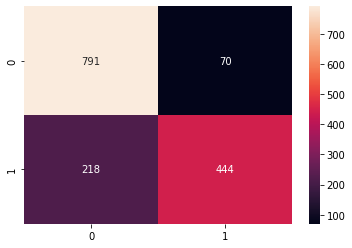

In [26]:
# plot the confusion matrix
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='.4g');

the main difference, now the models decreased the 'False Negative' & increased the 'True Negative'

# Submit results

In [27]:
# read the test data
test_df = pd.read_csv('/kaggle/input/nlp-getting-started/test.csv')

# read the submission file
sample_submission = pd.read_csv("/kaggle/input/nlp-getting-started/sample_submission.csv")

In [28]:
# predict the tweet class using the best pipeline
y_submit = better_pipeline.predict(test_df.text)

# assign the predictions to the submission df
sample_submission.target = y_submit
sample_submission.head()

,id,target
0,0,0
1,2,1
2,3,1
3,9,0
4,11,1


In [29]:
sample_submission.target.value_counts()

0    2208
1    1055
Name: target, dtype: int64

In [30]:
# save the submission df to a csv file
sample_submission.to_csv("submission.csv", index=False)

**For any suggestions, please let me know in the comments! Thanks.**

**Happy Learning🤗**